In [1]:
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fin_df      = pd.read_csv("../data/financials.csv")
opportunity = pd.read_csv("../data/latam_opportunity.csv")
sap_revenue = pd.read_csv("../data/sap_revenue.csv")
comp_table  = pd.read_csv("../data/comparable_analysis.csv")

print("Datos cargados OK")

Datos cargados OK


In [2]:
sap = fin_df[fin_df["company"] == "SAP"].iloc[0]
peers = fin_df[fin_df["company"] != "SAP"]

peer_median_ev_rev = peers["ev_revenue"].median()
upside = ((peer_median_ev_rev * sap["revenue_ttm"] - sap["enterprise_value"]) / sap["enterprise_value"] * 100).round(1)

print("=" * 60)
print("SAP SE — INVESTMENT THESIS SUMMARY")
print("=" * 60)
print(f"""
VALUATION
  Current EV/Revenue:      {sap['ev_revenue']:.2f}x
  Peer Median EV/Revenue:  {peer_median_ev_rev:.2f}x
  Implied upside:          +{upside}% (revenue-based)
  EV/EBITDA vs peers:      Fairly valued (16.2x vs 16.0x median)

CLOUD TRANSITION
  Cloud % of revenue 2019: 25.2%
  Cloud % of revenue 2023: 43.8%
  CAGR cloud revenue:      ~18.5% per year

LATAM OPPORTUNITY
  Brazil risk-adj. market: $0.55bn (priority market)
  Mexico risk-adj. market: $0.33bn (stable growth)
  Argentina risk-adj.:     $0.04bn (high risk, monitor)
  Total Latam addressable: $0.88bn by 2027

CONCLUSION
  SAP is undervalued on revenue multiples relative to peers,
  reflecting market skepticism about its cloud transition speed.
  However, with cloud revenue growing ~18.5% annually and Latam
  representing an underpenetrated high-growth region (12.3% CAGR),
  SAP offers a compelling risk-adjusted opportunity for long-term investors.
""")
print("=" * 60)

SAP SE — INVESTMENT THESIS SUMMARY

VALUATION
  Current EV/Revenue:      5.02x
  Peer Median EV/Revenue:  8.09x
  Implied upside:          +61.2% (revenue-based)
  EV/EBITDA vs peers:      Fairly valued (16.2x vs 16.0x median)

CLOUD TRANSITION
  Cloud % of revenue 2019: 25.2%
  Cloud % of revenue 2023: 43.8%
  CAGR cloud revenue:      ~18.5% per year

LATAM OPPORTUNITY
  Brazil risk-adj. market: $0.55bn (priority market)
  Mexico risk-adj. market: $0.33bn (stable growth)
  Argentina risk-adj.:     $0.04bn (high risk, monitor)
  Total Latam addressable: $0.88bn by 2027

CONCLUSION
  SAP is undervalued on revenue multiples relative to peers,
  reflecting market skepticism about its cloud transition speed.
  However, with cloud revenue growing ~18.5% annually and Latam
  representing an underpenetrated high-growth region (12.3% CAGR),
  SAP offers a compelling risk-adjusted opportunity for long-term investors.



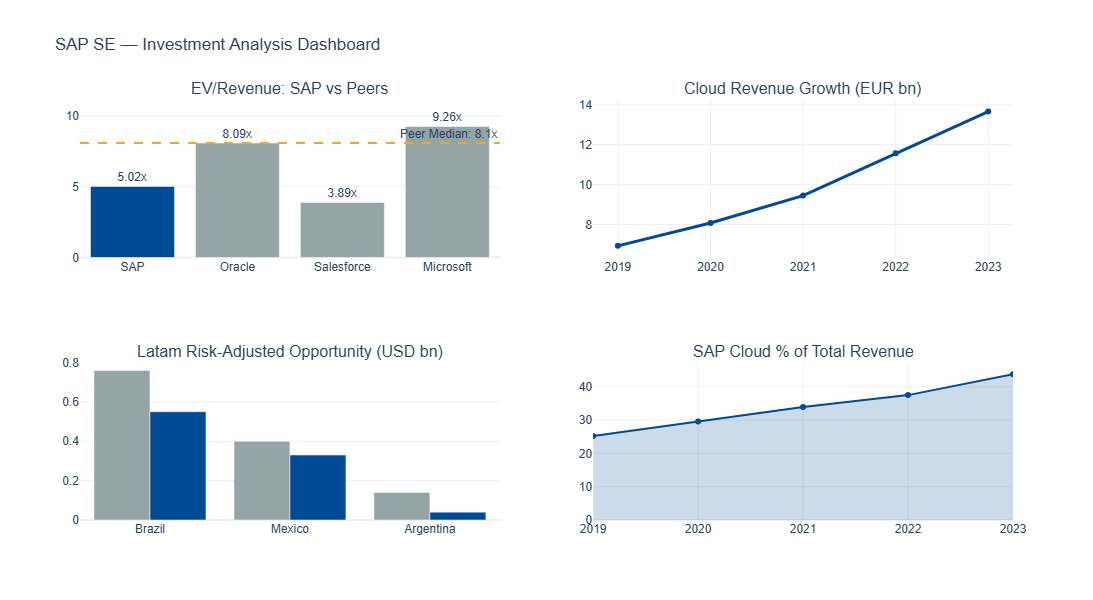

In [3]:
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "EV/Revenue: SAP vs Peers",
        "Cloud Revenue Growth (EUR bn)",
        "Latam Risk-Adjusted Opportunity (USD bn)",
        "SAP Cloud % of Total Revenue"
    )
)

# 1. EV/Revenue comparison
companies_plot = comp_table[comp_table["company"] != "Peer Median"]
colors_bar = ["#004A96" if c == "SAP" else "#95A5A6" for c in companies_plot["company"]]

fig.add_trace(go.Bar(
    x=companies_plot["company"],
    y=companies_plot["ev_revenue"],
    marker_color=colors_bar,
    showlegend=False,
    text=companies_plot["ev_revenue"].astype(str) + "x",
    textposition="outside"
), row=1, col=1)

# Peer median line
fig.add_hline(
    y=peer_median_ev_rev,
    line_dash="dash",
    line_color="#F5A623",
    annotation_text=f"Peer Median: {peer_median_ev_rev:.1f}x",
    row=1, col=1
)

# 2. Cloud revenue growth
fig.add_trace(go.Scatter(
    x=sap_revenue["year"],
    y=sap_revenue["cloud_revenue"],
    mode="lines+markers",
    line=dict(color="#004A96", width=3),
    showlegend=False
), row=1, col=2)

# 3. Latam opportunity
fig.add_trace(go.Bar(
    x=opportunity["country"],
    y=opportunity["sap_addressable"],
    name="Addressable",
    marker_color="#95A5A6",
    showlegend=False
), row=2, col=1)

fig.add_trace(go.Bar(
    x=opportunity["country"],
    y=opportunity["risk_adjusted_opportunity"],
    name="Risk-Adjusted",
    marker_color="#004A96",
    showlegend=False
), row=2, col=1)

# 4. Cloud % evolution
fig.add_trace(go.Scatter(
    x=sap_revenue["year"],
    y=sap_revenue["cloud_pct"],
    mode="lines+markers",
    fill="tozeroy",
    line=dict(color="#004A96", width=2),
    fillcolor="rgba(0, 74, 150, 0.2)",
    showlegend=False
), row=2, col=2)

fig.update_layout(
    title="SAP SE — Investment Analysis Dashboard",
    template="plotly_white",
    font=dict(family="Arial", size=12),
    height=600,
    barmode="group"
)

fig.show()

In [4]:
print("Project complete. Files saved:")
import os
for f in os.listdir("../data"):
    size = os.path.getsize(f"../data/{f}")
    print(f"  {f}: {size/1024:.1f} KB")

Project complete. Files saved:
  comparable_analysis.csv: 0.2 KB
  erp_market.csv: 0.3 KB
  financials.csv: 0.5 KB
  latam_opportunity.csv: 0.2 KB
  prices.csv: 210.6 KB
  prices_normalized.csv: 279.9 KB
  sap_regional.csv: 0.2 KB
  sap_revenue.csv: 0.2 KB
